In [ ]:
with open("robot_gpu_lib_version.txt","w") as f:
    f.write("# conda install -c conda-forge cudatoolkit=11.2 cudnn=8.1\n")
    f.write("pip install tensorflow==2.10\n")
    f.write('pip install "numpy<2"\n')
    f.write('pip install "pandas<2.2.2"\n')
    f.write('pip install "matplotlib<3.9"')


In [ ]:
# 나중 새로운 가상환경에서
# pip install -r robot_gpu_lib_version.txt
 
print("1456")
# 실행했을 때
# 드는 팝업에서 "설치" 클릭

1456


In [3]:
import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))
device = tf.config.experimental.list_physical_devices("GPU")
if device:
    try:
        tf.config.experimental.set_memory_growth(device[0], True)
        print("VRAM 12GB 메모리 제한 완료")
    except:
        print("GPU 없음")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU 없음


In [5]:
%pip install "pandas<2.2.2"

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   ---------------------------------------- 11.6/11.6 MB 72.6 MB/s  0:00:00
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/2 [tzdata]
  Attempting uninstall: pandas
   ---------------------------------------- 0/2 [tzdata]
    Found existing installation: pandas 2.3.3
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
    Uninstalling pandas-2.3.3:
   -------------------- ------------------- 1/2 [pandas]
      Successfully uninstalled pandas-2.3.3
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   ---

  You can safely remove it manually.
  You can safely remove it manually.


In [1]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
import numpy as np

In [6]:
# 세 번째 딥러닝
df = pd.read_csv("train.csv")
df_tt = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].copy()

df_tt = df_tt.dropna()
df_tt = pd.get_dummies(df_tt, dtype=int)
X = df_tt.iloc[:, 1 : ]
y = df_tt.iloc[:, 0]


model = Sequential()
model.add(Dense(28, input_dim=7, activation="relu", name="layer_1"))
model.add(Dense(50, input_dim=28, activation="relu", name="layer_2"))
model.add(Dense(1, input_dim=50, activation="sigmoid", name="layer_3"))

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(X, y, epochs=200, batch_size=64)

print(f"정확도 : {np.average(history.history['accuracy']) *100 :.4f}%")
print(f"최대값 : {np.max(history.history['accuracy']) *100: .4f}%")

Epoch 1/200
12/12 [==============================] - 0s 2ms/step - loss: 3.0099 - accuracy: 0.4062
Epoch 2/200
12/12 [==============================] - 0s 2ms/step - loss: 0.9456 - accuracy: 0.5252
Epoch 3/200
12/12 [==============================] - 0s 2ms/step - loss: 0.7457 - accuracy: 0.6611
Epoch 4/200
12/12 [==============================] - 0s 2ms/step - loss: 0.6777 - accuracy: 0.6877
Epoch 5/200
12/12 [==============================] - 0s 2ms/step - loss: 0.6155 - accuracy: 0.6821
Epoch 6/200
12/12 [==============================] - 0s 3ms/step - loss: 0.6022 - accuracy: 0.6989
Epoch 7/200
12/12 [==============================] - 0s 2ms/step - loss: 0.5909 - accuracy: 0.6961
Epoch 8/200
12/12 [==============================] - 0s 2ms/step - loss: 0.5998 - accuracy: 0.7003
Epoch 9/200
12/12 [==============================] - 0s 2ms/step - loss: 0.5855 - accuracy: 0.6919
Epoch 10/200
12/12 [==============================] - 0s 2ms/step - loss: 0.5857 - accuracy: 0.7045
Epoch 11/

In [7]:
%pip install "matplotlib<3.9"

   ---------------------------------------- 0.0/7.7 MB ? eta -:--:--
   ---------------------------------------  7.6/7.7 MB 39.3 MB/s eta 0:00:01
   ---------------------------------------- 7.7/7.7 MB 36.4 MB/s  0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.8
    Uninstalling matplotlib-3.10.8:
      Successfully uninstalled matplotlib-3.10.8
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import load_iris
iris_data = load_iris()
X = iris_data.data
y = iris_data.target
import pandas as pd
y = pd.get_dummies(y, dtype=int)

# 적층
model = Sequential()
model.add(Dense(12, input_dim=4, activation="relu"))
model.add(Dense(8, activation="relu")) # 생략해도 이전 층 데이터보고 가져옴
model.add(Dense(3, activation="softmax")) # 마지막 출력층 노드가 3개다!! (class 3개 data)
# model.summary() # 모델 파라미터 등 확인

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
# batch_size는 16개라면
# 현재 X에 있는 150개 데이터를 16개 단위로 끊어
# 학습 후 가중치를 오차에 역전파(back_propagation) 형태로 갱신
# ex. 4070 정도면 64개도 돌아감
model.fit(X, y, epochs=1000, batch_size=64)


Epoch 1/1000
3/3 [==============================] - 0s 4ms/step - loss: 1.0942 - categorical_accuracy: 0.3333
Epoch 2/1000
3/3 [==============================] - 0s 3ms/step - loss: 1.0763 - categorical_accuracy: 0.3333
Epoch 3/1000
3/3 [==============================] - 0s 3ms/step - loss: 1.0605 - categorical_accuracy: 0.3333
Epoch 4/1000
3/3 [==============================] - 0s 3ms/step - loss: 1.0453 - categorical_accuracy: 0.3333
Epoch 5/1000
3/3 [==============================] - 0s 2ms/step - loss: 1.0299 - categorical_accuracy: 0.3400
Epoch 6/1000
3/3 [==============================] - 0s 3ms/step - loss: 1.0158 - categorical_accuracy: 0.3400
Epoch 7/1000
3/3 [==============================] - 0s 4ms/step - loss: 1.0010 - categorical_accuracy: 0.4067
Epoch 8/1000
3/3 [==============================] - 0s 2ms/step - loss: 0.9864 - categorical_accuracy: 0.5067
Epoch 9/1000
3/3 [==============================] - 0s 3ms/step - loss: 0.9736 - categorical_accuracy: 0.5867
Epoch 10/1

In [ ]:
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
mine = np.loadtxt("https://github.com/nayeho/robot/raw/refs/heads/main/data/sonar3.csv", delimiter=",")
mine.shape # 0 ~ 59가 feature, 60 = class

array([[0.02  , 0.0371, 0.0428, ..., 0.009 , 0.0032, 0.    ],
       [0.0453, 0.0523, 0.0843, ..., 0.0052, 0.0044, 0.    ],
       [0.0262, 0.0582, 0.1099, ..., 0.0095, 0.0078, 0.    ],
       ...,
       [0.0522, 0.0437, 0.018 , ..., 0.0077, 0.0031, 1.    ],
       [0.0303, 0.0353, 0.049 , ..., 0.0036, 0.0048, 1.    ],
       [0.026 , 0.0363, 0.0136, ..., 0.0061, 0.0115, 1.    ]])

In [20]:
X = mine[:, : 60]
y = mine[:, 60] # 광석이면 1, 일반 암석이면 0

# 정확도가 100%가 나와서 train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=20)


# 마지막 출력층 : 1 -> sigmoid
# compile 옵션에 loss : binary_crossentropy
# 자유롭게 학습해서
# accuracy 출력!!

model = Sequential()
model.add(Dense(30, input_dim=60, activation="relu"))
model.add(Dense(60, activation="relu")) 
model.add(Dense(1, activation="sigmoid"))

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.fit(X_train, y_train, epochs=300, batch_size=32, verbose=False)

# split 한 test 결과로 모델 평가
score = model.evaluate(X_test, y_test)
print(score)
# print(f"정확도 : {np.average(history.history['accuracy']) *100 :.4f}%")
# print(f"최대값 : {np.max(history.history['accuracy']) *100: .4f}%")

2/2 [==============================] - 0s 2ms/step - loss: 0.6147 - accuracy: 0.8462
[0.6147461533546448, 0.8461538553237915]


In [ ]:
# 정확도가 100% -> 과적합(overfitting) 우려
# overfitting -> train, test split 필요
# split 한 test 결과로 모델 평가
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.fit(X_train, y_train, epochs=1000, batch_size=64, verbose=False)

score = model.evaluate(X_test, y_test)
print(score)

2/2 [==============================] - 0s 2ms/step - loss: 1.0544 - accuracy: 0.8077
[1.054389476776123, 0.807692289352417]


In [21]:
# 모델 저장 및 불러오기
# 모델을 저장하는 폴더를 만들자
import os
if not os.path.exists("models"):
    os.mkdir("models")
    print("폴더 생성 완료")
else:
    print("폴더가 이미 존재합니다")

폴더 생성 완료


In [ ]:
# 모델 저장
model.save("models/mine_200.keras")

In [ ]:
# 모델 불러오기
from tensorflow.keras.models import load_model
model2 = load_model("models/mine_200.keras")
model2.evaluate(X_test, y_test)

# k겹 교차 검증
# 데이터 수를 늘리는 방법
from sklearn.model_selection import KFold
k = 5 # 데이터를 5분할하여 train, test를 5번 실행!
kfold = KFold(n_splits=k, shuffle=True)

2/2 [==============================] - 0s 4ms/step - loss: 0.6147 - accuracy: 0.8462


[0.6147461533546448, 0.8461538553237915]

In [34]:
model = Sequential()
model.add(Dense(30, input_dim=60, activation="relu"))
model.add(Dense(60, activation="relu")) 
model.add(Dense(1, activation="sigmoid"))
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

acc_list = [] # 5개의 평가지표(정확도)를 담는 리스트!
for train_index, test_index in kfold.split(X):
    X_train, X_test = X[train_index, :], X[test_index, :]
    y_train, y_test = y[train_index], y[test_index]
    # k를 5로 설정해서 여기서 좀 5번이 돔 -> 딥러닝 진행
    model.fit(X_train, y_train, epochs=100, batch_size=64, verbose=False)
    score = model.evaluate(X_test, y_test)
    acc_list.append(score[1])

print(f"5겹 교차 검증 정확도 : {np.average(acc_list)}")

2/2 [==============================] - 0s 0s/step - loss: 0.0041 - accuracy: 1.0000
5겹 교차 검증 정확도 : 0.9428571343421936


In [35]:
!curl -L https://github.com/nayeho/robot/raw/refs/heads/main/data/wine.csv -o wine.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100  352k  100  352k    0     0   674k      0 --:--:-- --:--:-- --:--:--  674k


In [ ]:
df_wine = pd.read_csv("wine.csv", names=list(range(13)))
df_wine.iloc[:,12].value_counts()
# wine 1: Red Wine, wine 0: White Wine

# 검증 데이터셋(validation) : 622 - 학습셋, 검증셋, 테스트셋

X = df_wine.iloc[:, :12]
y = df_wine.iloc[:, 12]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

model = Sequential()
model.add(Dense(24, input_dim=12, activation="relu"))
model.add(Dense(12, input_dim=24, activation="relu"))
model.add(Dense(1, input_dim=12, activation="sigmoid"))


model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.fit(X_train, y_train, epochs=100, batch_size=64, verbose=False, validation_split=0.25)
# 검증 데이터셋 : 0.25 / 학습 0.75
# Total : 학습 0.6 / 검증 0.2 / 테스트 0.2 가 됨


In [ ]:
score = model.evaluate(X_test, y_test)
score

41/41 [==============================] - 0s 2ms/step - loss: 0.0663 - accuracy: 0.9823


In [ ]:
# 중간에 학습 100번 중에 진짜 성능 좋은 순간
# 그 때, 모델을 저장해보자
from tensorflow.keras.callbacks import ModelCheckpoint
check = ModelCheckpoint(filepath="models", verbose=True)
model.fit(X_train, y_train, epochs=100, batch_size=64, verbose=False,
          validation_split=0.25, callbacks=[check])



Epoch 1: saving model to models
INFO:tensorflow:Assets written to: models\assets

Epoch 2: saving model to models
INFO:tensorflow:Assets written to: models\assets

Epoch 3: saving model to models
INFO:tensorflow:Assets written to: models\assets

Epoch 4: saving model to models
INFO:tensorflow:Assets written to: models\assets

Epoch 5: saving model to models
INFO:tensorflow:Assets written to: models\assets

Epoch 6: saving model to models
INFO:tensorflow:Assets written to: models\assets

Epoch 7: saving model to models
INFO:tensorflow:Assets written to: models\assets

Epoch 8: saving model to models
INFO:tensorflow:Assets written to: models\assets

Epoch 9: saving model to models
INFO:tensorflow:Assets written to: models\assets

Epoch 10: saving model to models
INFO:tensorflow:Assets written to: models\assets

Epoch 11: saving model to models
INFO:tensorflow:Assets written to: models\assets

Epoch 12: saving model to models
INFO:tensorflow:Assets written to: models\assets

Epoch 13: sa

In [1]:
# 지금까지 배웠던 내용 토대로 진행
!curl -L https://github.com/nayeho/robot/raw/refs/heads/main/data/house_train.csv -o house.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100  449k  100  449k    0     0  3791k      0 --:--:-- --:--:-- --:--:-- 3791k


In [12]:
df_house = pd.read_csv("house.csv")
# df_house.keys() # 아마 saleprice가 메인
# df_house.info() # 결측치 확인
df_house.isnull().sum().sort_values(ascending=False).head(20) # 19개까지 결측
# DataFrame의 빈 데이터
# isnull() : 비어 있으면 True
# sum() : 비어있는 개수를 총합
# sort_values() : 정렬
# ascending=False : 내림차순
# 출력결과가 생략되니 head()를 통해서 정말 몇 개 결측인지 확인

# One-Hot Encoding
df_house = pd.get_dummies(df_house, dtype=int)

# 결측치 채워보자 : 평균으로 채우기
df_house = df_house.fillna(df_house.mean())


In [25]:
# 288개의 feature, 1개 정답 (SalePrice)
# 상관계수 확인!!
df_corr = df_house.corr()
df_corr.sort_values("SalePrice", ascending=False)["SalePrice"].head(10)

# 상위 데이터 확인 후 5개 긁어오기
X = df_house[["OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF"]]
y = df_house["SalePrice"]
print(X.shape, y.shape) # 갯수 맞는지 잘 확인

(1460, 5) (1460,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

# 자유롭게 적층!!
model = Sequential()
model.add(Dense(20, input_dim=5, activation="relu"))
model.add(Dense(12, input_dim=20, activation="relu"))
model.add(Dense(8, input_dim=12, activation="relu"))
# 분류가 아니나!! 회귀(주택 가격)
model.add(Dense(1)) # 마지막 출력층
model.compile(loss="mean_squared_error", optimizer="adam", metrics=["accuracy"])
model.fit(X_train, y_train, epochs=100, batch_size=64, verbose=False, validation_split=0.25)

In [ ]:
score = model.evaluate(X_test, y_test)
np.sqrt(score) # rmse : 43643

10/10 [==============================] - 0s 2ms/step - loss: 1904735616.0000 - accuracy: 0.0000e+00


array([43643.27687056,     0.        ])

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
5


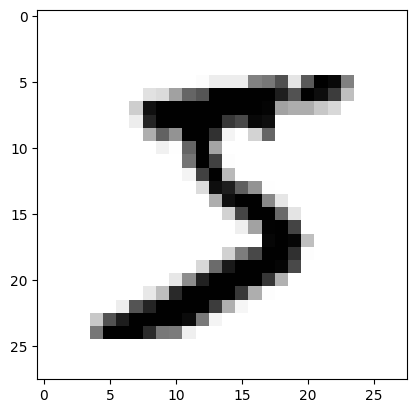

In [38]:
# 로봇 비전 프로젝트
# CNN
# 이제 시각적 -> 조금 재밌을지도
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# tuple 한꺼번에 가져오기
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

import matplotlib.pyplot as plt
plt.imshow(X_train[0], cmap="binary")
print(y_train[0]) # label
plt.show()


In [39]:
# 컴퓨터가 이해하는 방식으로 출력
for x in X_train[0]:
    for i in x:
        print(f"{i:3d}", end=" ")
    print()

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0 
  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0 
  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0 
  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   0   0   0   0 

In [44]:
# (28, 28) -> reshape 차원을 1차원으로 낮추기
X_train = X_train.reshape(X_train.shape[0], 784)
X_train.shape

(60000, 784)

In [66]:
del (X_train, X_test, y_train, y_test)

In [ ]:
# 안쪽 0 ~ 255 지정되어있는 값 -> 0 ~ 1 로
X_train[0].astype("float64") / 255.0
# 값이 너무 많아서 다 0이 된거처럼 짤림

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [ ]:
# 전체를 0 ~ 255 -> 0 ~ 1 로
X_train = X_train.reshape(X_train.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)


X_train = X_train.astype("float64") / 255.0
X_test = X_test.astype("float64") / 255.0

from keras import utils
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

In [ ]:
# 각 이미지가 28 * 28 -> 784로 평탄화
# 1층 : 784개 입력 -> 512개의 노드, 활성화 함수 relu
# 출력층 : softmax 10개의 클래스에 대한 확률
model = Sequential()
model.add(Dense(512, input_dim=784, activation="relu"))
model.add(Dense(10, activation="softmax"))

# 학습 할 모델을 설계
# 모델을 설계하기 싫어요 -> 만들어진 모델을 쓰자 (YOLO)
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.25)
# 노드, 가중치 정답에 가까워지는 규칙

# 이미지 데이터 -> CNN
# Dense -> ANN (인공 신경망)
# (28 X 28) -> CNN (합성곱 신경망)
#              ㄴConvolutional Neural Network
# ㄴ Convolution layer(합성곱 층): 특징을 대략적으로 추출해서 학습 가능

Epoch 1/100
704/704 [==============================] - 2s 2ms/step - loss: 0.2568 - accuracy: 0.9255 - val_loss: 0.1452 - val_accuracy: 0.9577
Epoch 2/100
704/704 [==============================] - 1s 2ms/step - loss: 0.1038 - accuracy: 0.9695 - val_loss: 0.1082 - val_accuracy: 0.9681
Epoch 3/100
704/704 [==============================] - 1s 2ms/step - loss: 0.0654 - accuracy: 0.9808 - val_loss: 0.0984 - val_accuracy: 0.9701
Epoch 4/100
704/704 [==============================] - 1s 1ms/step - loss: 0.0451 - accuracy: 0.9866 - val_loss: 0.0939 - val_accuracy: 0.9735
Epoch 5/100
704/704 [==============================] - 1s 2ms/step - loss: 0.0329 - accuracy: 0.9903 - val_loss: 0.0884 - val_accuracy: 0.9744
Epoch 6/100
704/704 [==============================] - 1s 1ms/step - loss: 0.0232 - accuracy: 0.9934 - val_loss: 0.0934 - val_accuracy: 0.9739
Epoch 7/100
704/704 [==============================] - 1s 2ms/step - loss: 0.0172 - accuracy: 0.9954 - val_loss: 0.0861 - val_accuracy: 0.9763

In [ ]:
score = model.evaluate(X_test, y_test)
score # 약 98%로 손글씨 탐색 가능

# 웹캠 (혹은 쓴 손글씨) -> 28 X 28 로 처리 0 ~ 1 -> 숫자 5야
#                          ㄴ로직으로 구현 필요

# 변경했을때 0.01 정도 성능 올라가는거 확인 가능

313/313 [==============================] - 1s 2ms/step - loss: 0.0862 - accuracy: 0.9894


[0.08623854070901871, 0.9894000291824341]

In [ ]:
# 이미지 데이터 -> CNN
# Dense -> ANN (인공 신경망)
# (28 X 28) -> CNN (합성곱 신경망)
#              ㄴConvolutional Neural Network
# ㄴ Convolution layer(합성곱 층): 특징을 대략적으로 추출해서 학습 가능

from tensorflow.keras.layers import Conv2D, Flatten, MaxPooling2D, Dropout
# MaxPooling2D, Dropout 추가

model = Sequential()
# model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(28, 28, 1), activation="relu"))
#                 필터개수(like Node)                      Gray=1, RGB=3
model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(28, 28, 1), activation="relu"))
model.add(Conv2D(64, kernel_size=(3, 3), input_shape=(28, 28, 1), activation="relu"))
model.add(Flatten()) # 2차원 이상의 데이터 -> 1차원으로 바꾸는 기능 (평탄화)
model.add(Dense(512, input_dim=784, activation="relu"))
model.add(Dense(10, activation="softmax"))

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(X_train, y_train, epochs=100, batch_size=256, validation_split=0.25)

Epoch 1/100
176/176 [==============================] - 30s 9ms/step - loss: 0.1755 - accuracy: 0.9470 - val_loss: 0.0662 - val_accuracy: 0.9800
Epoch 2/100
176/176 [==============================] - 1s 7ms/step - loss: 0.0386 - accuracy: 0.9879 - val_loss: 0.0602 - val_accuracy: 0.9826
Epoch 3/100
176/176 [==============================] - 1s 7ms/step - loss: 0.0191 - accuracy: 0.9940 - val_loss: 0.0594 - val_accuracy: 0.9821
Epoch 4/100
176/176 [==============================] - 1s 7ms/step - loss: 0.0102 - accuracy: 0.9970 - val_loss: 0.0536 - val_accuracy: 0.9860
Epoch 5/100
176/176 [==============================] - 1s 7ms/step - loss: 0.0070 - accuracy: 0.9976 - val_loss: 0.0592 - val_accuracy: 0.9845
Epoch 6/100
176/176 [==============================] - 1s 7ms/step - loss: 0.0048 - accuracy: 0.9986 - val_loss: 0.0643 - val_accuracy: 0.9870
Epoch 7/100
176/176 [==============================] - 1s 7ms/step - loss: 0.0060 - accuracy: 0.9980 - val_loss: 0.0558 - val_accuracy: 0.986

In [10]:
# 이미지 데이터 -> CNN
# Dense -> ANN (인공 신경망)
# (28 X 28) -> CNN (합성곱 신경망)
#              ㄴConvolutional Neural Network
# ㄴ Convolution layer(합성곱 층): 특징을 대략적으로 추출해서 학습 가능

from tensorflow.keras.layers import Conv2D, Flatten, MaxPooling2D, Dropout
# MaxPooling2D, Dropout 추가

model = Sequential()
# model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(28, 28, 1), activation="relu"))
#                 필터개수(like Node)                      Gray=1, RGB=3
model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(28, 28, 1), activation="relu"))
model.add(Conv2D(64, kernel_size=(3, 3), input_shape=(28, 28, 1), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2))) # 2x2 영역에서 가장 큰 값만 추출
model.add(Dropout(0.25)) # 25% 노드(필터) 끄자
model.add(Flatten()) # 2차원 이상의 데이터 -> 1차원으로 바꾸는 기능 (평탄화)
model.add(Dense(128, input_dim=784, activation="relu"))
model.add(Dropout(0.5)) # 50% 노드(필터) 끄자
model.add(Dense(10, activation="softmax"))

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(X_train, y_train, epochs=100, batch_size=256, validation_split=0.25)

Epoch 1/100
176/176 [==============================] - 2s 9ms/step - loss: 0.3560 - accuracy: 0.8922 - val_loss: 0.0869 - val_accuracy: 0.9744
Epoch 2/100
176/176 [==============================] - 1s 5ms/step - loss: 0.1131 - accuracy: 0.9664 - val_loss: 0.0617 - val_accuracy: 0.9804
Epoch 3/100
176/176 [==============================] - 1s 5ms/step - loss: 0.0786 - accuracy: 0.9762 - val_loss: 0.0510 - val_accuracy: 0.9843
Epoch 4/100
176/176 [==============================] - 1s 5ms/step - loss: 0.0659 - accuracy: 0.9802 - val_loss: 0.0495 - val_accuracy: 0.9851
Epoch 5/100
176/176 [==============================] - 1s 5ms/step - loss: 0.0579 - accuracy: 0.9820 - val_loss: 0.0444 - val_accuracy: 0.9865
Epoch 6/100
176/176 [==============================] - 1s 5ms/step - loss: 0.0474 - accuracy: 0.9851 - val_loss: 0.0469 - val_accuracy: 0.9869
Epoch 7/100
176/176 [==============================] - 1s 5ms/step - loss: 0.0454 - accuracy: 0.9860 - val_loss: 0.0420 - val_accuracy: 0.9878

In [ ]:
score = model.evaluate(X_test, y_test)
score # 조금 더 올라간 성능 확인 가능

313/313 [==============================] - 1s 2ms/step - loss: 0.0508 - accuracy: 0.9928


[0.05080718919634819, 0.9927999973297119]

In [1]:
# YOLO (You Only Look Once)
# 이미 만들어진 모델
# 가져다쓰자
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...


In [ ]:
!pip install git-python

In [ ]:
!pip install "ultralytics>=8.2.64"

In [ ]:
!python yolov5/detect.py --source 0

Traceback (most recent call last):
  File "c:\Users\kccistc\Desktop\workspace\yolov5\detect.py", line 38, in <module>
    import torch
ModuleNotFoundError: No module named 'torch'


In [ ]:
import os
os.listdir("yolov5")

import glob
glob.glob("yolov5/*.py")

['yolov5\\benchmarks.py',
 'yolov5\\detect.py',
 'yolov5\\export.py',
 'yolov5\\hubconf.py',
 'yolov5\\train.py',
 'yolov5\\val.py']

In [ ]:
# import 관련
from tensorflow.keras import Sequential
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense
import os
import glob
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.model_selection import KFold
from tensorflow.keras.datasets import mnist
from sklearn.datasets import load_iris
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
from keras import utils
from tensorflow.keras.layers import Conv2D, Flatten, MaxPooling2D, Dropout
import numpy as np

In [6]:
# 데이터 관련
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# (28, 28) -> reshape 차원을 1차원으로 낮춤
# CNN 시 1차원으로 낮추지 말자~~
# X_train = X_train.reshape(X_train.shape[0], 784)
# X_test = X_test.reshape(X_test.shape[0], 784)

# 전체를 0 ~ 255 -> 0 ~ 1
X_train = X_train.astype("float64") / 255.0
X_test = X_test.astype("float64") / 255.0

y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)